# Project I: Image Classification with CNNs
## CINIC-10 Dataset — Deep Learning, Warsaw University of Technology, 2026

Complete experiment pipeline:
1. **Dataset Exploration** — class distribution, sample images
2. **Model Architectures** — parameter counts, design rationale
3. **Architecture Comparison** — Baseline, Deep, Efficient, RegularisedCNN (15 epochs)
4. **Hyperparameter Analysis** — learning rate, batch size, optimizer, regularisation
5. **Data Augmentation** — visual comparison + performance impact
6. **Statistical Significance** — 3-seed reproducibility test
7. **Few-Shot Learning** — naive baseline (§7.1) + Prototypical Networks (§7.2)
8. **Reduced Dataset** — accuracy vs. training set size
9. **Final Test Evaluation** — baseline model on held-out test split
10. **Ensemble Methods** — hard & soft voting across independent models
11. **Best Architecture** — EfficientCNN trained to convergence, full test evaluation
12. **Summary & Key Findings**


In [1]:
# ── Environment setup (local / Colab GPU / Colab TPU) ────────────────────────
import sys, os, subprocess
from pathlib import Path
from collections import defaultdict

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    # Colab ships CUDA-enabled torch/torchvision — do NOT reinstall them.
    # For TPU runtimes, torch_xla is pre-installed; no extra install needed.
    subprocess.run(["pip", "install", "-q", "--no-deps", "tqdm"], check=True)

    if not Path("/content/cinic10-cnn-project").exists():
        subprocess.run(["git", "clone", "--quiet",
                        "https://github.com/telechubby/cinic10-cnn-project.git",
                        "/content/cinic10-cnn-project"], check=True)
        print("Repo cloned.")
    else:
        subprocess.run(["git", "-C", "/content/cinic10-cnn-project",
                        "pull", "--quiet"], check=True)
        print("Repo up-to-date.")

    PROJECT_ROOT = Path("/content/cinic10-cnn-project")

    # ── Data: mount Drive if CINIC-10 is stored there ─────────────────────
    # from google.colab import drive; drive.mount("/content/drive")
    # import shutil
    # shutil.copytree("/content/drive/MyDrive/cinic10", str(PROJECT_ROOT / "data"))

else:
    PROJECT_ROOT = Path(os.path.abspath("")).resolve()
    if PROJECT_ROOT.name == "notebooks":
        PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report

from utils import get_device, set_seeds, train_model
from model_architecture import (
    create_baseline_cnn, create_deep_cnn,
    create_efficient_cnn, create_cnn_with_regularization,
    CINIC_CLASSES,
)
from data_preprocessing import create_data_generators

import random as _rand
# ── Reproducible randomness ────────────────────────────────────────────────
# MASTER_SEED drives every random decision in this notebook.
# Leave as-is for a fresh run; hardcode a printed value to reproduce a run.
MASTER_SEED = _rand.randint(10_000, 99_999)
del _rand
_seed_rng   = np.random.default_rng(MASTER_SEED)
SEEDS       = _seed_rng.integers(1_000, 9_999, size=3).tolist()
del _seed_rng
print(f"Master seed : {MASTER_SEED}")
print(f"Run seeds   : {SEEDS}")
print("(hardcode MASTER_SEED above to reproduce this exact run)")

set_seeds(SEEDS[0])
device = get_device()

# ── Diagnostics ───────────────────────────────────────────────────────────────
print(f"torch {torch.__version__}")
print(f"CUDA : {torch.cuda.is_available()}" +
      (f" ({torch.cuda.get_device_name(0)})" if torch.cuda.is_available() else ""))
try:
    import torch_xla.core.xla_model as xm
    print(f"TPU  : {xm.xla_device()}")
except ImportError:
    print("TPU  : not available")
print(f"MPS  : {torch.backends.mps.is_available()}")
print(f"Device in use: {device}")
print(f"Project root : {PROJECT_ROOT}")

TRAIN_DIR  = PROJECT_ROOT / "data" / "train"
VAL_DIR    = PROJECT_ROOT / "data" / "valid"
TEST_DIR   = PROJECT_ROOT / "data" / "test"
RESULTS    = PROJECT_ROOT / "results"
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)

plt.rcParams.update({"figure.dpi": 110, "font.size": 11})
print("Setup complete.")


Master seed : 23991
Run seeds   : [7992, 9582, 4470]
(hardcode MASTER_SEED above to reproduce this exact run)
torch 2.11.0
CUDA : False
TPU  : not available
MPS  : True
Device in use: mps
Project root : /Users/ljubomirkolev/Politechnika Warszawska/Deep Learning/Project 1
Setup complete.


---
## 1. Dataset Exploration

CINIC-10 contains **270,000 images** across **10 classes** (90k train / 90k valid / 90k test),  
each 32×32 RGB. It extends CIFAR-10 with downsampled ImageNet images, making it harder than CIFAR-10.

            Train  Validation  Test
airplane     9000        9000  9000
automobile   9000        9000  9000
bird         9000        9000  9000
cat          9000        9000  9000
deer         9000        9000  9000
dog          9000        9000  9000
frog         9000        9000  9000
horse        9000        9000  9000
ship         9000        9000  9000
truck        9000        9000  9000

Total images: 270,000


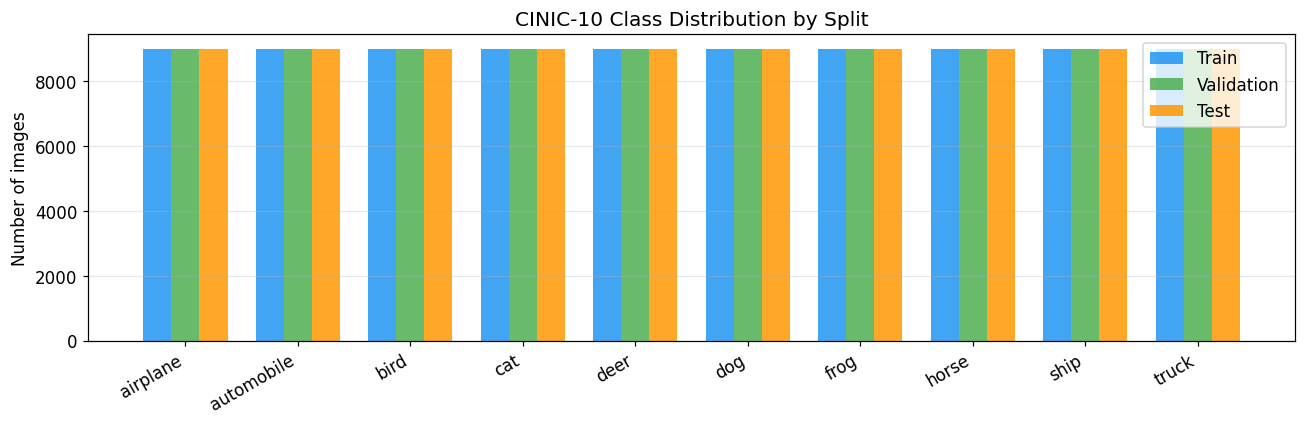

In [2]:
splits = {'Train': TRAIN_DIR, 'Validation': VAL_DIR, 'Test': TEST_DIR}
counts = {}
for split_name, split_dir in splits.items():
    counts[split_name] = {cls: len(list((split_dir / cls).iterdir()))
                          for cls in CINIC_CLASSES}

df_counts = pd.DataFrame(counts)
print(df_counts.to_string())
print(f'\nTotal images: {df_counts.sum().sum():,}')

fig, ax = plt.subplots(figsize=(12, 4))
x = np.arange(len(CINIC_CLASSES))
w = 0.25
for i, (split_name, color) in enumerate(zip(splits, ['#2196F3', '#4CAF50', '#FF9800'])):
    ax.bar(x + i * w, df_counts[split_name], w, label=split_name, color=color, alpha=0.85)
ax.set_xticks(x + w)
ax.set_xticklabels(CINIC_CLASSES, rotation=30, ha='right')
ax.set_ylabel('Number of images')
ax.set_title('CINIC-10 Class Distribution by Split')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS / 'dataset_class_distribution.png', bbox_inches='tight')
plt.show()

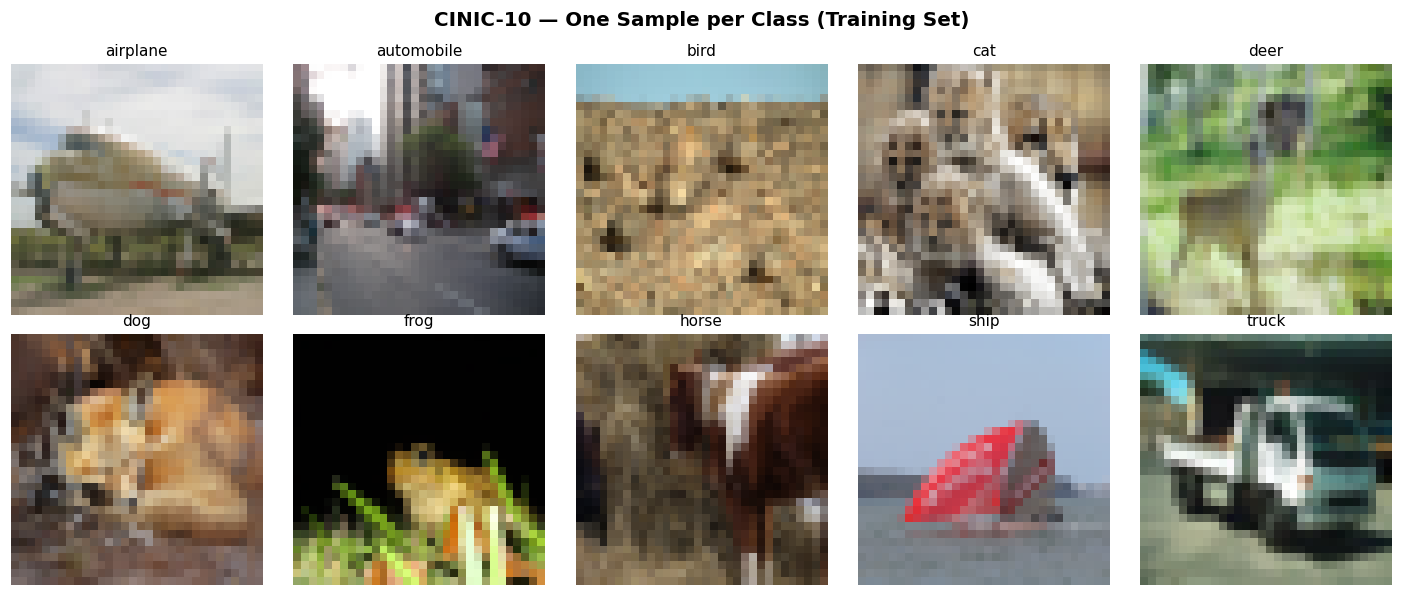

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(13, 5.5))
fig.suptitle('CINIC-10 — One Sample per Class (Training Set)', fontsize=13, fontweight='bold')
for ax, cls in zip(axes.flat, CINIC_CLASSES):
    img_path = next((TRAIN_DIR / cls).iterdir())
    img = Image.open(img_path).convert('RGB')
    ax.imshow(img)
    ax.set_title(cls, fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.savefig(RESULTS / 'dataset_sample_images.png', bbox_inches='tight')
plt.show()

---
## 2. Model Architectures

We define and compare **four CNN architectures**, all operating on 32×32 RGB input with 10-class output:

| Model | Conv blocks | Channels | Classifier head | Key feature |
|-------|------------|----------|-----------------|-------------|
| **BaselineCNN** | 3 | 32→64→128 | 2048→512→10 | Reference model |
| **DeepCNN** | 4 | 32→64→128→256 | 1024→512→10 | Deeper feature extraction |
| **EfficientCNN** | 3 | 32→64→128 | 2048→256→10 | Compact head, lower dropout |
| **CNNWithRegularization** | 3 | 32→64→128 | 2048→512→10 | Configurable dropout |

All blocks follow **Conv→BN→ReLU** ordering with MaxPool + Dropout2d between blocks.

In [4]:
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

arch_configs = [
    ('BaselineCNN',           create_baseline_cnn,           {}),
    ('DeepCNN',               create_deep_cnn,               {}),
    ('EfficientCNN',          create_efficient_cnn,          {}),
    ('CNNWithRegularization', create_cnn_with_regularization, {'dropout_rate': 0.1}),
]

rows = []
for name, factory, kwargs in arch_configs:
    m = factory(**kwargs)
    n = count_params(m)
    rows.append({'Architecture': name, 'Parameters': f'{n:,}'})

df_params = pd.DataFrame(rows)
print(df_params.to_string(index=False))

         Architecture Parameters
          BaselineCNN  1,342,698
              DeepCNN  2,755,818
         EfficientCNN    815,082
CNNWithRegularization  1,342,698


---
## 3. Architecture Comparison

All architectures trained under identical conditions:  
Adam (lr=0.001), batch size 32, 15 epochs, no augmentation, early stopping patience=5.

Results are cached to `results/arch_comparison.csv` after the first run.

Training all architectures (this takes a few minutes)...

--- BaselineCNN (1,342,698 params) ---


Epoch   1/15  loss 1.7174  acc 0.3603  val_loss 1.3953  val_acc 0.4880  *best*


Epoch   2/15  loss 1.4335  acc 0.4736  val_loss 1.2097  val_acc 0.5572  *best*


Epoch   3/15  loss 1.3169  acc 0.5212  val_loss 1.1220  val_acc 0.5928  *best*


Epoch   4/15  loss 1.2419  acc 0.5515  val_loss 1.0984  val_acc 0.6019  *best*


...

Epoch  11/15  loss 0.6502  acc 0.7669  val_loss 0.8584  val_acc 0.7057  *best*


Epoch  12/15  loss 0.6155  acc 0.7802  val_loss 0.8718  val_acc 0.7004


Epoch  13/15  loss 0.5816  acc 0.7904  val_loss 0.8779  val_acc 0.7046


Epoch  14/15  loss 0.5539  acc 0.8005  val_loss 0.8894  val_acc 0.7026


Epoch  15/15  loss 0.5268  acc 0.8105  val_loss 0.9125  val_acc 0.7037

Saved to /Users/ljubomirkolev/Politechnika Warszawska/Deep Learning/Project 1/results/arch_comparison.csv


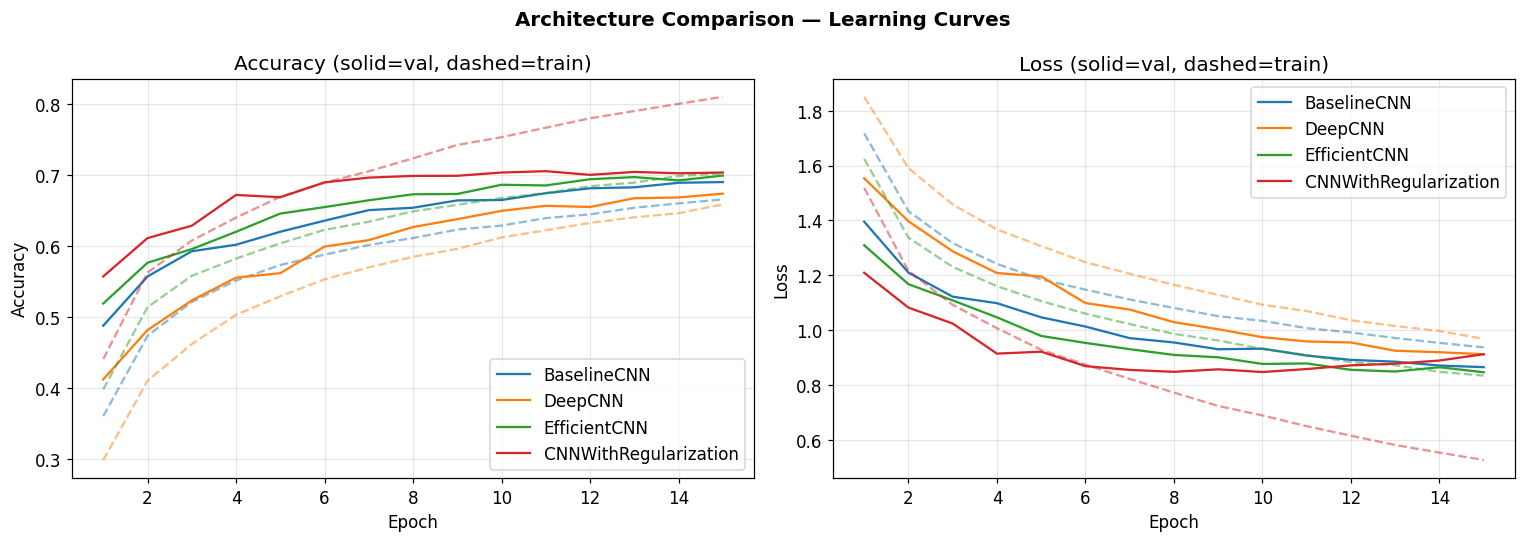

         architecture  best_val_accuracy
          BaselineCNN           0.690289
              DeepCNN           0.674000
         EfficientCNN           0.699444
CNNWithRegularization           0.705656


In [5]:
ARCH_CSV    = RESULTS / 'arch_comparison.csv'
ARCH_EPOCHS = 15

if ARCH_CSV.exists():
    print('Loading pre-computed architecture results...')
    df_arch = pd.read_csv(ARCH_CSV)
    arch_histories = None  # not available when loading from cache
else:
    print('Training all architectures (this takes a few minutes)...')
    train_loader, val_loader = create_data_generators(
        str(TRAIN_DIR), str(VAL_DIR), batch_size=32, augment=False
    )
    arch_results   = []
    arch_histories = {}

    for name, factory, kwargs in arch_configs:
        set_seeds(SEEDS[0])
        model     = factory(**kwargs).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
        print(f'\n--- {name} ({count_params(model):,} params) ---')
        history = train_model(
            model, train_loader, val_loader, optimizer,
            epochs=ARCH_EPOCHS, device=device, patience=5,
        )
        arch_histories[name] = history
        arch_results.append({
            'architecture':      name,
            'best_val_accuracy': max(history['val_accuracy']),
            'final_val_accuracy': history['val_accuracy'][-1],
            'final_val_loss':    history['val_loss'][-1],
            'epochs_trained':    len(history['val_accuracy']),
        })

    df_arch = pd.DataFrame(arch_results)
    df_arch.to_csv(ARCH_CSV, index=False)
    print(f'\nSaved to {ARCH_CSV}')

    # --- Learning curves ---
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for (name, _, __), color in zip(arch_configs, colors):
        h  = arch_histories[name]
        ep = range(1, len(h['val_accuracy']) + 1)
        axes[0].plot(ep, h['accuracy'],     '--', color=color, alpha=0.5)
        axes[0].plot(ep, h['val_accuracy'], '-',  color=color, label=name)
        axes[1].plot(ep, h['loss'],         '--', color=color, alpha=0.5)
        axes[1].plot(ep, h['val_loss'],     '-',  color=color, label=name)
    for ax, ylabel, title in zip(
        axes,
        ['Accuracy', 'Loss'],
        ['Accuracy (solid=val, dashed=train)', 'Loss (solid=val, dashed=train)'],
    ):
        ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
        ax.set_title(title); ax.legend(); ax.grid(alpha=0.3)
    plt.suptitle('Architecture Comparison — Learning Curves', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(RESULTS / 'arch_learning_curves.png', bbox_inches='tight')
    plt.show()

col = 'best_val_accuracy' if 'best_val_accuracy' in df_arch.columns else 'val_accuracy'
print(df_arch[['architecture', col]].to_string(index=False))

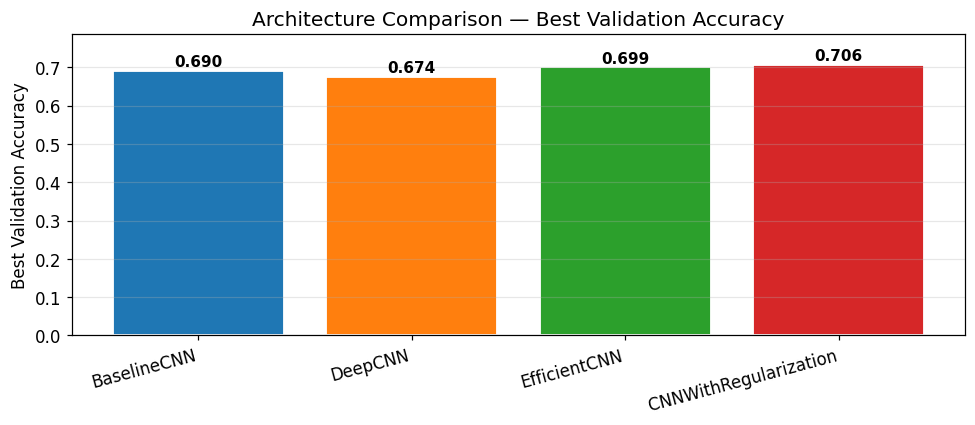

In [6]:
col    = 'best_val_accuracy' if 'best_val_accuracy' in df_arch.columns else 'val_accuracy'
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(df_arch['architecture'], df_arch[col],
              color=colors[:len(df_arch)], edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, df_arch[col]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.004,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Best Validation Accuracy')
ax.set_title('Architecture Comparison — Best Validation Accuracy')
ax.set_ylim(0, min(1.0, df_arch[col].max() + 0.08))
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig(RESULTS / 'arch_comparison_bar.png', bbox_inches='tight')
plt.show()

---
## 4. Hyperparameter Analysis

Each sweep uses **BaselineCNN trained for 5 epochs** on the full training set.  \
One parameter is varied at a time; all others held at defaults:  \
lr=0.001, batch=32, Adam, dropout=0.25, wd=0.

Four sweeps are conducted:
1. **Learning rate** — governs gradient step size; tested: {0.0001, 0.001, 0.01, 0.1}
2. **Batch size** — controls gradient noise and memory; tested: {16, 32, 64}
3. **Optimizer** — update rule; compared: Adam, SGD, RMSprop
4. **Regularisation** — grid of dropout_rate × weight_decay; the two main regularisation  \
   hyperparameters, covering dropout={0.1, 0.2, 0.3, 0.5} and wd={1e-4, 1e-3, 1e-2}

All sweeps are cached in `results/hp_*.csv`.


In [ ]:
# ── Generate HP sweep CSVs (skip if already present) ─────────────────────────
_hp_paths = [RESULTS / f'hp_{k}.csv'
             for k in ('learning_rate', 'batch_size', 'optimizer', 'regularization')]
if not all(p.exists() for p in _hp_paths):
    print("Running HP sweeps (≈10-20 min on CPU, much faster on GPU/MPS)…")
    from hyperparameter_analysis import create_comprehensive_hyperparameter_analysis
    _hp = create_comprehensive_hyperparameter_analysis(
        create_baseline_cnn, str(TRAIN_DIR), str(VAL_DIR)
    )
    RESULTS.mkdir(exist_ok=True)
    for _key, _rows in _hp.items():
        pd.DataFrame(_rows).to_csv(RESULTS / f'hp_{_key}.csv', index=False)
        print(f"  saved hp_{_key}.csv")
else:
    print("HP CSVs found — skipping sweep.")


In [8]:
df_lr = pd.read_csv(RESULTS / 'hp_learning_rate.csv')
df_lr['learning_rate'] = df_lr['learning_rate'].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x = np.arange(len(df_lr)); w = 0.35

axes[0].bar(x - w/2, df_lr['train_accuracy'], w, label='Train', color='#2196F3', alpha=0.85)
axes[0].bar(x + w/2, df_lr['val_accuracy'],   w, label='Val',   color='#4CAF50', alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(df_lr['learning_rate'])
axes[0].set_xlabel('Learning Rate'); axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy vs Learning Rate'); axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(x - w/2, df_lr['train_loss'], w, label='Train', color='#F44336', alpha=0.85)
axes[1].bar(x + w/2, df_lr['val_loss'],   w, label='Val',   color='#FF9800', alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(df_lr['learning_rate'])
axes[1].set_xlabel('Learning Rate'); axes[1].set_ylabel('Loss')
axes[1].set_title('Loss vs Learning Rate'); axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Hyperparameter Analysis — Learning Rate', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS / 'hp_lr_plot.png', bbox_inches='tight')
plt.show()

best = df_lr.loc[df_lr['val_accuracy'].idxmax()]
print(f'Best LR: {best["learning_rate"]} — val_acc={best["val_accuracy"]:.4f}')
print('Note: lr=0.1 collapses to random-chance accuracy (10%) — gradient steps are too large.')

FileNotFoundError: [Errno 2] No such file or directory: '/Users/ljubomirkolev/Politechnika Warszawska/Deep Learning/Project 1/results/hp_learning_rate.csv'

In [ ]:
df_bs = pd.read_csv(RESULTS / 'hp_batch_size.csv')
df_bs['batch_size'] = df_bs['batch_size'].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
x = np.arange(len(df_bs)); w = 0.35

axes[0].bar(x - w/2, df_bs['train_accuracy'], w, label='Train', color='#2196F3', alpha=0.85)
axes[0].bar(x + w/2, df_bs['val_accuracy'],   w, label='Val',   color='#4CAF50', alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(df_bs['batch_size'])
axes[0].set_xlabel('Batch Size'); axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy vs Batch Size'); axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(x - w/2, df_bs['train_loss'], w, label='Train', color='#F44336', alpha=0.85)
axes[1].bar(x + w/2, df_bs['val_loss'],   w, label='Val',   color='#FF9800', alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(df_bs['batch_size'])
axes[1].set_xlabel('Batch Size'); axes[1].set_ylabel('Loss')
axes[1].set_title('Loss vs Batch Size'); axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Hyperparameter Analysis — Batch Size', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS / 'hp_bs_plot.png', bbox_inches='tight')
plt.show()

best = df_bs.loc[df_bs['val_accuracy'].idxmax()]
print(f'Best batch size: {best["batch_size"]} — val_acc={best["val_accuracy"]:.4f}')

In [ ]:
df_opt = pd.read_csv(RESULTS / 'hp_optimizer.csv')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
x = np.arange(len(df_opt)); w = 0.35
names = df_opt['optimizer'].str.upper()

axes[0].bar(x - w/2, df_opt['train_accuracy'], w, label='Train', color='#2196F3', alpha=0.85)
axes[0].bar(x + w/2, df_opt['val_accuracy'],   w, label='Val',   color='#4CAF50', alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(names)
axes[0].set_xlabel('Optimizer'); axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy vs Optimizer'); axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(x - w/2, df_opt['train_loss'], w, label='Train', color='#F44336', alpha=0.85)
axes[1].bar(x + w/2, df_opt['val_loss'],   w, label='Val',   color='#FF9800', alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(names)
axes[1].set_xlabel('Optimizer'); axes[1].set_ylabel('Loss')
axes[1].set_title('Loss vs Optimizer'); axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Hyperparameter Analysis — Optimizer', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS / 'hp_opt_plot.png', bbox_inches='tight')
plt.show()

best = df_opt.loc[df_opt['val_accuracy'].idxmax()]
print(f'Best optimizer: {best["optimizer"]} — val_acc={best["val_accuracy"]:.4f}')

In [ ]:
df_reg = pd.read_csv(RESULTS / 'hp_regularization.csv')

pivot_acc  = df_reg.pivot(index='dropout_rate', columns='weight_decay', values='val_accuracy')
pivot_loss = df_reg.pivot(index='dropout_rate', columns='weight_decay', values='val_loss')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.heatmap(pivot_acc,  ax=axes[0], annot=True, fmt='.3f', cmap='YlGn',
            linewidths=0.5, cbar_kws={'label': 'Val Accuracy'})
axes[0].set_title('Validation Accuracy')
axes[0].set_xlabel('Weight Decay'); axes[0].set_ylabel('Dropout Rate')

sns.heatmap(pivot_loss, ax=axes[1], annot=True, fmt='.3f', cmap='YlOrRd_r',
            linewidths=0.5, cbar_kws={'label': 'Val Loss'})
axes[1].set_title('Validation Loss')
axes[1].set_xlabel('Weight Decay'); axes[1].set_ylabel('Dropout Rate')

plt.suptitle('Regularisation Grid Search — Dropout × Weight Decay', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS / 'hp_reg_heatmap.png', bbox_inches='tight')
plt.show()

best = df_reg.loc[df_reg['val_accuracy'].idxmax()]
print(f'Best: dropout={best["dropout_rate"]}, wd={best["weight_decay"]} '
      f'→ val_acc={best["val_accuracy"]:.4f}')
print('Note: dropout=0.5 collapses training to random guessing (10%) regardless of weight decay.')

---
## 5. Data Augmentation Study

We compare **seven augmentation pipelines** on BaselineCNN (5 epochs, lr=0.001, batch=32).  \
For reference, the no-augmentation baseline achieves **61.8% val accuracy** at 5 epochs  \
(from the LR sweep, §4.1).

### 5.1 Visual Comparison of Transform Pipelines


In [ ]:
sample_path = next((TRAIN_DIR / 'airplane').iterdir())
src = Image.open(sample_path).convert('RGB')

augmentation_pipelines = {
    'Original': T.Compose([T.Resize((32, 32)), T.ToTensor()]),
    'Standard\n(rot+flip+aff)': T.Compose([
        T.Resize((32, 32)), T.RandomRotation(15),
        T.RandomHorizontalFlip(), T.ColorJitter(brightness=0.2, contrast=0.2),
        T.ToTensor(),
    ]),
    'Color\nJitter': T.Compose([
        T.Resize((32, 32)),
        T.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
        T.ToTensor(),
    ]),
    'Minimal\n(flip only)': T.Compose([
        T.Resize((32, 32)), T.RandomHorizontalFlip(p=1.0), T.ToTensor(),
    ]),
    'Crop +\nResize': T.Compose([
        T.Resize((38, 38)), T.RandomCrop(32), T.ToTensor(),
    ]),
}

set_seeds(SEEDS[0])
fig, axes = plt.subplots(1, len(augmentation_pipelines), figsize=(14, 3))
fig.suptitle('Standard Augmentation Pipelines — Same Source Image', fontsize=12, fontweight='bold')
for ax, (name, transform) in zip(axes, augmentation_pipelines.items()):
    tensor = transform(src)
    ax.imshow(tensor.permute(1, 2, 0).numpy().clip(0, 1))
    ax.set_title(name, fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.savefig(RESULTS / 'aug_standard_vis.png', bbox_inches='tight')
plt.show()

In [ ]:
# Cutout: zero-out a random square patch of the image
def apply_cutout(img_tensor, mask_size):
    result = img_tensor.clone()
    _, h, w = result.shape
    cy = np.random.randint(mask_size // 2, h - mask_size // 2)
    cx = np.random.randint(mask_size // 2, w - mask_size // 2)
    y1, y2 = max(0, cy - mask_size // 2), min(h, cy + mask_size // 2)
    x1, x2 = max(0, cx - mask_size // 2), min(w, cx + mask_size // 2)
    result[:, y1:y2, x1:x2] = 0.0
    return result

base_tensor = T.Compose([T.Resize((32, 32)), T.ToTensor()])(src)
set_seeds(SEEDS[0])
variants = {'No Cutout': base_tensor}
for sz in [8, 12, 16, 20]:
    variants[f'Cutout\nmask={sz}'] = apply_cutout(base_tensor.clone(), sz)

fig, axes = plt.subplots(1, len(variants), figsize=(13, 3))
fig.suptitle('Cutout Augmentation — Effect of Mask Size', fontsize=12, fontweight='bold')
for ax, (name, tensor) in zip(axes, variants.items()):
    ax.imshow(tensor.permute(1, 2, 0).numpy().clip(0, 1))
    ax.set_title(name, fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.savefig(RESULTS / 'aug_cutout_vis.png', bbox_inches='tight')
plt.show()

### 5.2 Augmentation Performance Comparison

In [ ]:
# ── Generate augmentation CSVs (skip if already present) ─────────────────────
_aug_paths = [RESULTS / 'aug_standard.csv', RESULTS / 'aug_advanced.csv']
if not all(p.exists() for p in _aug_paths):
    print("Running augmentation comparison (≈10 min on CPU)…")
    from augmentation_studies import compare_augmentation_approaches
    _aug = compare_augmentation_approaches(
        create_baseline_cnn, str(TRAIN_DIR), str(VAL_DIR), epochs=5, batch_size=32
    )
    RESULTS.mkdir(exist_ok=True)
    for _key, _rows in _aug.items():
        pd.DataFrame(_rows).to_csv(RESULTS / f'aug_{_key}.csv', index=False)
        print(f"  saved aug_{_key}.csv")
else:
    print("Augmentation CSVs found — skipping.")


In [ ]:
df_std = pd.read_csv(RESULTS / 'aug_standard.csv')
df_adv = pd.read_csv(RESULTS / 'aug_advanced.csv')

label_map_std = {
    'standard':    'Standard\n(rot+flip+aff)',
    'color_jitter':'Color Jitter',
    'minimal':     'Minimal\n(flip only)',
    'crop_resize': 'Crop+Resize',
}
label_map_adv = {
    'cutout':           'Cutout',
    'mixup':            'Mixup',
    'autoaugment_like': 'AutoAugment-like',
}
df_std['label'] = df_std['augmentation'].map(label_map_std).fillna(df_std['augmentation'])
df_adv['label'] = df_adv['augmentation'].map(label_map_adv).fillna(df_adv['augmentation'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, df, title in [
    (axes[0], df_std, 'Standard Augmentation Techniques (×3 required)'),
    (axes[1], df_adv, 'Advanced Augmentation Techniques (×1 required)'),
]:
    x = np.arange(len(df)); w = 0.35
    ax.bar(x - w/2, df['train_accuracy'], w, label='Train', color='#2196F3', alpha=0.85)
    bars = ax.bar(x + w/2, df['val_accuracy'], w, label='Val', color='#4CAF50', alpha=0.85)
    for bar, val in zip(bars, df['val_accuracy']):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(df['label'], fontsize=9)
    ax.set_ylabel('Accuracy (5 epochs)')
    ax.set_title(title); ax.legend(); ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, 0.80)

plt.suptitle('Data Augmentation Study — Validation Accuracy', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS / 'aug_comparison_bar.png', bbox_inches='tight')
plt.show()

best_std = df_std.loc[df_std['val_accuracy'].idxmax()]
best_adv = df_adv.loc[df_adv['val_accuracy'].idxmax()]
print(f'Best standard: {best_std["augmentation"]:15s} val_acc={best_std["val_accuracy"]:.4f}')
print(f'Best advanced: {best_adv["augmentation"]:15s} val_acc={best_adv["val_accuracy"]:.4f}')

---
## 6. Statistical Significance

Single-run results can be misleading due to random initialisation variance.  \
We repeat two key configurations **3 times with different seeds** and report **mean ± std**.

Configurations compared:
- **Baseline**: Adam lr=0.001, dropout=0.25 (default), no weight decay, no augmentation
- **Best Reg.**: same optimiser, dropout=0.1, weight\_decay=1e-4 (best from HP sweep §4)

This directly validates whether the HP-optimised configuration reliably outperforms  \
the vanilla baseline — or whether the improvement could be a lucky seed.


In [ ]:
STATS_CSV   = RESULTS / 'statistical_significance.csv'
STAT_EPOCHS = 15

# We compare the vanilla baseline against the best HP-sweep configuration
# (CNNWithRegularization, dropout=0.1, wd=1e-4) — both trained WITHOUT augmentation
# so only the regularisation hyperparameters differ.
# Running 3 seeds each lets us distinguish real improvement from lucky initialisation.
configs = [
    # Vanilla baseline — no augmentation, default dropout=0.25
    ('Baseline\n(dropout=0.25, wd=0)',    create_baseline_cnn,
     {},  {},                False),
    # Best config from HP sweep: lower dropout + weight decay
    ('Best Reg.\n(dropout=0.1, wd=1e-4)', create_cnn_with_regularization,
     {'dropout_rate': 0.1}, {'weight_decay': 1e-4}, False),
]

if STATS_CSV.exists():
    print('Loading cached results...')
    df_stats = pd.read_csv(STATS_CSV)
else:
    rows = []
    for config_name, factory, model_kwargs, optim_kwargs, augment in configs:
        train_loader, val_loader = create_data_generators(
            str(TRAIN_DIR), str(VAL_DIR), batch_size=32, augment=augment
        )
        for seed in SEEDS:
            set_seeds(seed)
            model     = factory(**model_kwargs).to(device)
            optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, **optim_kwargs)
            label = config_name.replace('\n', ' ')
            print(f'{label}  seed={seed}')
            history = train_model(model, train_loader, val_loader, optimizer,
                                  epochs=STAT_EPOCHS, device=device, patience=5)
            rows.append({
                'config':         config_name,
                'seed':           seed,
                'best_val_acc':   max(history['val_accuracy']),
                'final_val_acc':  history['val_accuracy'][-1],
                'final_val_loss': history['val_loss'][-1],
            })

    df_stats = pd.DataFrame(rows)
    df_stats.to_csv(STATS_CSV, index=False)
    print(f'\nSaved to {STATS_CSV}')

summary = df_stats.groupby('config')['best_val_acc'].agg(['mean', 'std']).reset_index()
summary.columns = ['Configuration', 'Mean Val Acc', 'Std Dev']
summary['Mean \u00b1 Std'] = summary.apply(
    lambda r: f"{r['Mean Val Acc']:.4f} \u00b1 {r['Std Dev']:.4f}", axis=1)
print('\n', summary[['Configuration', 'Mean \u00b1 Std']].to_string(index=False))


In [ ]:
has_gap = 'train_val_gap' in df_stats.columns
ncols   = 2 if has_gap else 1
fig, axes_raw = plt.subplots(1, ncols, figsize=(13 if has_gap else 7, 5))
axes = list(axes_raw) if has_gap else [axes_raw]

configs_unique = df_stats['config'].unique()
x = np.arange(len(configs_unique))
w = 0.18
seed_colors = ['#64B5F6', '#42A5F5', '#1565C0']

ax0 = axes[0]
for i, (seed, color) in enumerate(zip(SEEDS, seed_colors)):
    vals = [
        df_stats[(df_stats['config'] == c) & (df_stats['seed'] == seed)]['best_val_acc'].values[0]
        for c in configs_unique
    ]
    ax0.bar(x + (i - 1) * w, vals, w, label=f'seed={seed}', alpha=0.75, color=color)

for j, cfg in enumerate(configs_unique):
    vals = df_stats[df_stats['config'] == cfg]['best_val_acc'].values
    ax0.errorbar(x[j], vals.mean(), yerr=vals.std(),
                 fmt='D', color='#F44336', capsize=6, markersize=7,
                 linewidth=2, label='Mean \u00b1 Std' if j == 0 else '')

ax0.set_xticks(x)
ax0.set_xticklabels(configs_unique, fontsize=9)
ax0.set_ylabel('Best Validation Accuracy')
ax0.set_title('Best Val Accuracy \u2014 3 Seeds per Config')
ax0.legend(fontsize=8); ax0.grid(axis='y', alpha=0.3)
ax0.set_ylim(0.55, 0.82)

if has_gap:
    gap_data = [df_stats[df_stats['config'] == c]['train_val_gap'].values for c in configs_unique]
    bp = axes[1].boxplot(gap_data, labels=configs_unique,
                         patch_artist=True, notch=False)
    for patch, color in zip(bp['boxes'], ['#90CAF9', '#EF9A9A']):
        patch.set_facecolor(color)
    axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
    axes[1].set_ylabel('Train Acc \u2212 Val Acc (final epoch)')
    axes[1].set_title('Overfitting Gap \u2014 lower is better')
    axes[1].grid(axis='y', alpha=0.3)
    axes[1].tick_params(axis='x', labelsize=9)

plt.suptitle('Statistical Significance \u2014 3 Seeds per Configuration',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS / 'stats_significance_plot.png', bbox_inches='tight')
plt.show()

print(df_stats.to_string(index=False))


---
## 7. Few-Shot Learning

### 7.1 Naive Baseline — Train from Scratch

`FewShotCNN` (uses global average pooling, so it accepts any input size)  \
is trained directly on K labelled examples per class and evaluated on the full  \
validation set. With K ≤ 10 there are fewer than 100 training images total —  \
the model cannot generalise and stays near random chance (10%).


In [ ]:
# ── Generate few-shot + reduced-dataset CSVs (skip if already present) ───────
_fs_csv = RESULTS / 'few_shot_results.csv'
_rd_csv = RESULTS / 'reduced_dataset_results.csv'

if not _fs_csv.exists():
    print("Running naive few-shot evaluation (≈5 min on CPU)…")
    from few_shot_learning import evaluate_few_shot_performance
    _fs = evaluate_few_shot_performance(
        create_few_shot_cnn, str(TRAIN_DIR), str(VAL_DIR),
        few_shot_configs=[1, 5, 10, 50], epochs=15, batch_size=32
    )
    RESULTS.mkdir(exist_ok=True)
    pd.DataFrame(_fs['few_shot']).to_csv(_fs_csv, index=False)
    print("  saved few_shot_results.csv")
else:
    print("few_shot_results.csv found — skipping.")

if not _rd_csv.exists():
    print("Running reduced-dataset experiment (≈5 min on CPU)…")
    from evaluation import run_reduced_dataset_experiment
    _rd = run_reduced_dataset_experiment(
        create_baseline_cnn, str(TRAIN_DIR), str(VAL_DIR),
        fractions=[0.1, 0.25, 0.5, 1.0], epochs=5, batch_size=32
    )
    RESULTS.mkdir(exist_ok=True)
    pd.DataFrame(_rd).to_csv(_rd_csv, index=False)
    print("  saved reduced_dataset_results.csv")
else:
    print("reduced_dataset_results.csv found — skipping.")


In [ ]:
df_fs = pd.read_csv(RESULTS / 'few_shot_results.csv')
df_rd = pd.read_csv(RESULTS / 'reduced_dataset_results.csv')
full_val_acc = df_rd.loc[df_rd['fraction'] == 1.0, 'val_accuracy'].values[0]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(df_fs['samples_per_class'], df_fs['val_accuracy'],
        'o-', color='#2196F3', linewidth=2, markersize=8, label='Few-Shot CNN')
ax.axhline(full_val_acc, color='#F44336', linestyle='--', linewidth=1.5,
           label=f'Full dataset baseline ({full_val_acc:.3f})')
ax.axhline(0.1, color='gray', linestyle=':', linewidth=1.2, label='Random chance (0.100)')

for _, row in df_fs.iterrows():
    ax.annotate(f"{row['val_accuracy']:.3f}",
                (row['samples_per_class'], row['val_accuracy']),
                textcoords='offset points', xytext=(6, 5), fontsize=9)

ax.set_xscale('log')
ax.set_xticks(df_fs['samples_per_class'])
ax.set_xticklabels(df_fs['samples_per_class'].astype(str))
ax.set_xlabel('Labelled Examples per Class (log scale)')
ax.set_ylabel('Validation Accuracy')
ax.set_title('Few-Shot Learning — Accuracy vs Labelled Examples per Class')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS / 'few_shot_plot.png', bbox_inches='tight')
plt.show()

print(df_fs[['samples_per_class', 'train_accuracy', 'val_accuracy', 'val_loss']].to_string(index=False))
print(f'\nFull-dataset baseline: {full_val_acc:.4f}')
gap = full_val_acc - df_fs['val_accuracy'].max()
print(f'Gap (full vs best few-shot): {gap:.4f}')

### 7.2 Prototypical Networks — Episodic Meta-Training

**Prototypical Networks** (Snell et al., 2017) address the failure above through  \
*episodic training*:
- Each step is an **N-way K-shot episode**: N classes, K support + Q query images each.
- A **class prototype** = mean embedding of its K support images.
- Queries are classified by **nearest prototype** (minimum L2 distance in embedding space).
- Loss = cross-entropy over negated distances — the network learns a metric space  \
  where same-class images cluster together.

At test time, prototypes are formed from new support images → **no fine-tuning needed**.


In [ ]:
class EmbeddingNetwork(nn.Module):
    """4-block CNN encoder → 64-dim L2-normalised embedding.
    Dropout2d(0.15) after each block regularises the feature maps.
    """
    def __init__(self, embedding_dim=64, dropout=0.15):
        super().__init__()
        def conv_block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1),
                nn.BatchNorm2d(out_ch), nn.ReLU(),
                nn.MaxPool2d(2), nn.Dropout2d(dropout),
            )
        self.encoder = nn.Sequential(
            conv_block(3, 64), conv_block(64, 64),
            conv_block(64, 64), conv_block(64, 64),
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
        )
        self.proj = nn.Linear(64, embedding_dim)

    def forward(self, x):
        z = self.proj(self.encoder(x))
        return F.normalize(z, dim=1)  # L2 normalise → unit hypersphere



enc = EmbeddingNetwork(embedding_dim=64)
print(f'EmbeddingNetwork parameters: {count_params(enc):,}')  # count_params defined in §2
test_out = enc(torch.zeros(2, 3, 32, 32))
print(f'Output shape: {test_out.shape}  (L2 norm: {test_out.norm(dim=1).mean():.3f})')


In [ ]:
class EpisodicDataset(torch.utils.data.Dataset):
    """Yields N-way K-shot episodes. Images are ordered: all support first, then all query."""
    def __init__(self, root, transform, n_way, k_shot, n_query, n_episodes):
        self.base     = ImageFolder(str(root), transform=transform)
        self.n_way    = n_way
        self.k_shot   = k_shot
        self.n_query  = n_query
        self.n_episodes = n_episodes
        self.class_to_idx = defaultdict(list)
        for idx, (_, label) in enumerate(self.base.samples):
            self.class_to_idx[label].append(idx)
        self.all_classes = sorted(self.class_to_idx)

    def __len__(self):
        return self.n_episodes

    def __getitem__(self, _):
        classes = np.random.choice(len(self.all_classes), self.n_way, replace=False)
        support_imgs, query_imgs, support_lbl, query_lbl = [], [], [], []
        for new_lbl, cls in enumerate(classes):
            idxs = np.random.choice(
                self.class_to_idx[self.all_classes[cls]],
                self.k_shot + self.n_query, replace=False
            )
            for i, idx in enumerate(idxs):
                img, _ = self.base[idx]
                if i < self.k_shot:
                    support_imgs.append(img); support_lbl.append(new_lbl)
                else:
                    query_imgs.append(img);   query_lbl.append(new_lbl)
        images = torch.stack(support_imgs + query_imgs)
        labels = torch.tensor(support_lbl + query_lbl, dtype=torch.long)
        return images, labels


def prototypical_step(model, images, n_way, k_shot, n_query, device):
    """Single episode forward. Returns (loss, accuracy)."""
    images = images.to(device)                            # (N*(K+Q), 3, H, W)
    z      = model(images)                                # (N*(K+Q), D)
    support_size = n_way * k_shot
    prototypes   = z[:support_size].view(n_way, k_shot, -1).mean(1)  # (N, D)
    queries      = z[support_size:]                       # (N*Q, D)
    dists        = torch.cdist(queries, prototypes)       # (N*Q, N)
    q_labels     = torch.arange(n_way).repeat_interleave(n_query).to(device)
    loss = F.cross_entropy(-dists, q_labels)
    acc  = (dists.argmin(1) == q_labels).float().mean().item()
    return loss, acc


transform = T.Compose([T.Resize((32, 32)), T.ToTensor()])
print('EpisodicDataset and prototypical_step defined.')

In [ ]:
PROTO_PT  = MODELS_DIR / 'protonet.pt'
PROTO_CSV = RESULTS    / 'protonet_training.csv'

N_WAY   = 10   # all 10 CINIC classes
K_SHOT  = 5    # 5 support examples per class
N_QUERY = 10   # 10 query examples per class
EPISODES_PER_EPOCH = 100   # fewer episodes → less memorisation per epoch
PROTO_EPOCHS       = 40

if PROTO_PT.exists():
    print('Loading cached ProtoNet weights...')
    proto_net = EmbeddingNetwork(embedding_dim=64).to(device)
    proto_net.load_state_dict(torch.load(PROTO_PT, map_location=device))
    if PROTO_CSV.exists():
        df_proto_hist = pd.read_csv(PROTO_CSV)
    else:
        df_proto_hist = pd.DataFrame()
else:
    set_seeds(SEEDS[0])
    proto_net = EmbeddingNetwork(embedding_dim=64).to(device)

    # Adam + weight decay (L2 reg on weights) + gradient clipping
    optimizer = torch.optim.Adam(proto_net.parameters(), lr=5e-4, weight_decay=1e-4)
    # Cosine annealing: smooth decay, avoids aggressive LR collapse of StepLR
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=PROTO_EPOCHS, eta_min=1e-5
    )

    # Training episodes: augmented transforms reduce overfitting
    train_transform = T.Compose([
        T.Resize((32, 32)),
        T.RandomCrop(32, padding=4),
        T.RandomHorizontalFlip(),
        T.ColorJitter(brightness=0.2, contrast=0.2),
        T.ToTensor(),
    ])
    val_transform = T.Compose([T.Resize((32, 32)), T.ToTensor()])

    train_ep_ds = EpisodicDataset(TRAIN_DIR, train_transform, N_WAY, K_SHOT, N_QUERY,
                                  n_episodes=EPISODES_PER_EPOCH * PROTO_EPOCHS)
    val_ep_ds   = EpisodicDataset(VAL_DIR,   val_transform,   N_WAY, K_SHOT, N_QUERY,
                                  n_episodes=200)

    train_ep_loader = DataLoader(train_ep_ds, batch_size=1, shuffle=False, num_workers=0)
    val_ep_loader   = DataLoader(val_ep_ds,   batch_size=1, shuffle=False, num_workers=0)

    history = []
    best_val_acc, best_state = 0.0, None
    patience_counter, patience = 0, 10

    ep_iter = iter(train_ep_loader)
    for epoch in range(PROTO_EPOCHS):
        # Training
        proto_net.train()
        t_losses, t_accs = [], []
        for _ in range(EPISODES_PER_EPOCH):
            imgs, _ = next(ep_iter)
            imgs = imgs.squeeze(0)
            optimizer.zero_grad()
            loss, acc = prototypical_step(proto_net, imgs, N_WAY, K_SHOT, N_QUERY, device)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(proto_net.parameters(), max_norm=5.0)
            optimizer.step()
            t_losses.append(loss.item()); t_accs.append(acc)

        # Validation
        proto_net.train(mode=False)
        v_losses, v_accs = [], []
        with torch.no_grad():
            for imgs, _ in val_ep_loader:
                imgs = imgs.squeeze(0)
                loss, acc = prototypical_step(proto_net, imgs, N_WAY, K_SHOT, N_QUERY, device)
                v_losses.append(loss.item()); v_accs.append(acc)
        proto_net.train()
        scheduler.step()

        row = {'epoch': epoch+1,
               'train_loss': np.mean(t_losses), 'train_acc': np.mean(t_accs),
               'val_loss':   np.mean(v_losses), 'val_acc':   np.mean(v_accs),
               'lr': optimizer.param_groups[0]['lr']}
        history.append(row)
        marker = ''
        if row['val_acc'] > best_val_acc:
            best_val_acc = row['val_acc']
            best_state   = {k: v.clone() for k, v in proto_net.state_dict().items()}
            patience_counter = 0
            marker = '  *best*'
        else:
            patience_counter += 1
        print(f'Epoch {epoch+1:3d}/{PROTO_EPOCHS}  '
              f'loss {row["train_loss"]:.4f}  acc {row["train_acc"]:.4f}  '
              f'val_loss {row["val_loss"]:.4f}  val_acc {row["val_acc"]:.4f}'
              f'{marker}')
        if patience_counter >= patience:
            print(f'Early stopping at epoch {epoch+1}')
            break

    proto_net.load_state_dict(best_state)
    torch.save(proto_net.state_dict(), PROTO_PT)
    df_proto_hist = pd.DataFrame(history)
    df_proto_hist.to_csv(PROTO_CSV, index=False)
    print(f'Best val_acc: {best_val_acc:.4f}  | Saved to {PROTO_PT}')


In [ ]:
# Plot training curves if available
if not df_proto_hist.empty:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(df_proto_hist['epoch'], df_proto_hist['train_acc'], '--', label='Train', alpha=0.7)
    axes[0].plot(df_proto_hist['epoch'], df_proto_hist['val_acc'],   '-',  label='Val')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Episode Accuracy')
    axes[0].set_title(f'ProtoNet Accuracy ({N_WAY}-way {K_SHOT}-shot)')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(df_proto_hist['epoch'], df_proto_hist['train_loss'], '--', label='Train', alpha=0.7)
    axes[1].plot(df_proto_hist['epoch'], df_proto_hist['val_loss'],   '-',  label='Val')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Prototypical Loss')
    axes[1].set_title('ProtoNet Loss'); axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.suptitle('Prototypical Network — Training History', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(RESULTS / 'protonet_training_curves.png', bbox_inches='tight')
    plt.show()

# ── N-way K-shot evaluation on test set ────────────────────────────────────
print('Evaluating ProtoNet on test set...')
proto_net.train(mode=False)

proto_results = []
N_EVAL_EPISODES = 600

for k_shot_eval in [1, 5]:
    test_ep_ds = EpisodicDataset(TEST_DIR, transform, N_WAY, k_shot_eval, N_QUERY,
                                 n_episodes=N_EVAL_EPISODES)
    test_ep_loader = DataLoader(test_ep_ds, batch_size=1, shuffle=False, num_workers=0)

    accs = []
    with torch.no_grad():
        for imgs, _ in test_ep_loader:
            imgs = imgs.squeeze(0)
            _, acc = prototypical_step(proto_net, imgs, N_WAY, k_shot_eval, N_QUERY, device)
            accs.append(acc)

    mean_acc = np.mean(accs)
    std_acc  = np.std(accs)
    ci95     = 1.96 * std_acc / np.sqrt(N_EVAL_EPISODES)
    proto_results.append({
        'k_shot': k_shot_eval,
        'mean_acc': mean_acc, 'std_acc': std_acc, 'ci95': ci95
    })
    print(f'  {N_WAY}-way {k_shot_eval}-shot: {mean_acc:.4f} ± {std_acc:.4f}  (95% CI ±{ci95:.4f})')

df_proto_eval = pd.DataFrame(proto_results)
df_proto_eval.to_csv(RESULTS / 'protonet_evaluation.csv', index=False)

In [ ]:
# Compare ProtoNet vs naive few-shot (from main notebook)
df_naive = pd.read_csv(RESULTS / 'few_shot_results.csv')

fig, ax = plt.subplots(figsize=(10, 5))

# Naive few-shot (x-axis: samples per class)
ax.plot(df_naive['samples_per_class'], df_naive['val_accuracy'],
        'o--', color='#F44336', linewidth=2, markersize=7, label='Naive (train from scratch)')

# ProtoNet 1-shot and 5-shot points
r1 = df_proto_eval[df_proto_eval['k_shot'] == 1].iloc[0]
r5 = df_proto_eval[df_proto_eval['k_shot'] == 5].iloc[0]
ax.errorbar([1],  [r1['mean_acc']], yerr=[r1['ci95']], fmt='s', color='#2196F3',
            capsize=7, markersize=9, linewidth=2, label=f'ProtoNet 1-shot ({r1["mean_acc"]:.3f} ± {r1["ci95"]:.3f})')
ax.errorbar([5],  [r5['mean_acc']], yerr=[r5['ci95']], fmt='s', color='#1565C0',
            capsize=7, markersize=9, linewidth=2, label=f'ProtoNet 5-shot ({r5["mean_acc"]:.3f} ± {r5["ci95"]:.3f})')

ax.axhline(0.1, color='gray', linestyle=':', linewidth=1.2, label='Random chance (0.100)')

ax.set_xscale('log')
ax.set_xticks([1, 5, 10, 50])
ax.set_xticklabels(['1', '5', '10', '50'])
ax.set_xlabel('Support Examples per Class (K)')
ax.set_ylabel('Accuracy')
ax.set_title('Few-Shot Learning Comparison: Prototypical Network vs Naive Baseline\n'
             f'({N_WAY}-way evaluation, {N_EVAL_EPISODES} episodes)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS / 'protonet_vs_naive.png', bbox_inches='tight')
plt.show()

print(f'Naive  1 sample/class: {df_naive.loc[df_naive["samples_per_class"]==1, "val_accuracy"].values[0]:.4f}')
print(f'Naive  5 samples/class: {df_naive.loc[df_naive["samples_per_class"]==5, "val_accuracy"].values[0]:.4f}')
print(f'ProtoNet 1-shot: {r1["mean_acc"]:.4f} ± {r1["ci95"]:.4f}')
print(f'ProtoNet 5-shot: {r5["mean_acc"]:.4f} ± {r5["ci95"]:.4f}')

---
## 8. Reduced Dataset Experiment

BaselineCNN trained on **10%, 25%, 50%, 100%** of training data (5 epochs each)  \
to understand how accuracy scales with dataset size.

**Epoch note:** this experiment uses 5 epochs (same as the HP sweep) to keep  \
compute budget manageable. For context, the full-data 15-epoch run (§3) reaches  \
68.9% — 8.4 pp higher than the 5-epoch 100%-data run here (60.5%).  \
The gap confirms that both data quantity and training duration matter independently.

**Link to §7 (Few-Shot):** the 10%-dataset point (9 000 samples, ~90/class) can be  \
compared to the naive few-shot experiment at 50 samples/class (28.2% val acc).  \
With 90 samples/class and standard supervised training the model reaches 39.3% —  \
a gain of +11 pp over the naive few-shot approach using 50 samples/class, showing  \
how much label-efficient meta-learning still has to bridge the gap with full supervision.


In [ ]:
df_rd = pd.read_csv(RESULTS / 'reduced_dataset_results.csv')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(df_rd['fraction'] * 100, df_rd['val_accuracy'],
             'o-', color='#2196F3', linewidth=2, markersize=8)
for _, row in df_rd.iterrows():
    axes[0].annotate(f"{row['val_accuracy']:.3f}",
                     (row['fraction'] * 100, row['val_accuracy']),
                     textcoords='offset points', xytext=(5, 5), fontsize=9)
axes[0].set_xlabel('Training Set Size (%)')
axes[0].set_ylabel('Validation Accuracy')
axes[0].set_title('Learning Curve (by fraction)')
axes[0].grid(alpha=0.3)

axes[1].plot(df_rd['num_train_samples'], df_rd['val_accuracy'],
             's-', color='#4CAF50', linewidth=2, markersize=8)
for _, row in df_rd.iterrows():
    axes[1].annotate(f"{int(row['num_train_samples']):,}",
                     (row['num_train_samples'], row['val_accuracy']),
                     textcoords='offset points', xytext=(4, -15), fontsize=8, color='gray')
axes[1].set_xlabel('Number of Training Samples')
axes[1].set_ylabel('Validation Accuracy')
axes[1].set_title('Learning Curve (by sample count)')
axes[1].grid(alpha=0.3)

plt.suptitle('Reduced Dataset Experiment — Accuracy vs Training Set Size',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS / 'reduced_dataset_plot.png', bbox_inches='tight')
plt.show()

acc_10  = df_rd.loc[df_rd['fraction'] == 0.10, 'val_accuracy'].values[0]
acc_100 = df_rd.loc[df_rd['fraction'] == 1.00, 'val_accuracy'].values[0]
print(f'Accuracy at 10% data:  {acc_10:.4f}')
print(f'Accuracy at 100% data: {acc_100:.4f}')
print(f'Gain 10% → 100%: +{acc_100 - acc_10:.4f}')

---
## 9. Final Test Set Evaluation

We load `baseline_cnn.pt` (20 epochs, full training set) and evaluate on the **held-out test split**  
(90,000 images never seen during training or hyperparameter selection).

In [ ]:
model_test = create_baseline_cnn().to(device)
model_test.load_state_dict(torch.load(MODELS_DIR / 'baseline_cnn.pt', map_location=device))
model_test.train(mode=False)   # inference mode: no dropout, BN uses running stats
print('Loaded baseline_cnn.pt')

test_transform = T.Compose([T.Resize((32, 32)), T.ToTensor()])
test_dataset   = ImageFolder(str(TEST_DIR), transform=test_transform)
test_loader    = DataLoader(test_dataset, batch_size=256, shuffle=False, num_workers=0)
print(f'Test samples: {len(test_dataset):,} | Classes: {test_dataset.classes}')

criterion = nn.CrossEntropyLoss()
test_loss, test_correct = 0.0, 0
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        logits = model_test(images)
        loss   = criterion(logits, labels)
        probs  = torch.softmax(logits, dim=1)
        preds  = logits.argmax(dim=1)
        test_loss    += loss.item() * images.size(0)
        test_correct += (preds == labels).sum().item()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)
test_acc   = test_correct / len(test_dataset)
test_loss /= len(test_dataset)

print(f'\nTest Accuracy: {test_acc:.4f}  ({test_correct:,}/{len(test_dataset):,})')
print(f'Test Loss:     {test_loss:.4f}')

In [ ]:
cm      = confusion_matrix(all_labels, all_preds, labels=list(range(10)))
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CINIC_CLASSES, yticklabels=CINIC_CLASSES,
            ax=axes[0], linewidths=0.4)
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
axes[0].set_title('Confusion Matrix (raw counts)')
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CINIC_CLASSES, yticklabels=CINIC_CLASSES,
            ax=axes[1], linewidths=0.4, vmin=0, vmax=1)
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
axes[1].set_title('Confusion Matrix (row-normalised recall)')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle(f'Test Set Confusion Matrix  |  Overall Accuracy: {test_acc:.4f}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS / 'test_confusion_matrix.png', bbox_inches='tight')
plt.show()

In [ ]:
per_class_acc = cm_norm.diagonal()

report    = classification_report(all_labels, all_preds,
                                  target_names=CINIC_CLASSES, output_dict=True)
df_report = pd.DataFrame(report).T.iloc[:10][['precision', 'recall', 'f1-score', 'support']]
df_report.index = CINIC_CLASSES
df_report = df_report.astype({'support': int})
print(df_report.round(3).to_string())

fig, ax = plt.subplots(figsize=(11, 4.5))
colors = ['#4CAF50' if a >= test_acc else '#F44336' for a in per_class_acc]
bars   = ax.bar(CINIC_CLASSES, per_class_acc, color=colors, edgecolor='white', linewidth=0.8)
ax.axhline(test_acc, color='#333', linestyle='--', linewidth=1.5,
           label=f'Overall accuracy ({test_acc:.3f})')
for bar, val in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Recall (per-class accuracy)')
ax.set_title('Per-Class Accuracy — green = above average, red = below average')
ax.set_ylim(0, 1.0); ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(RESULTS / 'test_perclass_accuracy.png', bbox_inches='tight')
plt.show()

print(f'Easiest class: {CINIC_CLASSES[np.argmax(per_class_acc)]:12s} ({per_class_acc.max():.3f})')
print(f'Hardest class: {CINIC_CLASSES[np.argmin(per_class_acc)]:12s} ({per_class_acc.min():.3f})')

In [ ]:
rng               = np.random.default_rng(seed=SEEDS[0])
idx_correct       = np.where(all_preds == all_labels)[0]
idx_incorrect     = np.where(all_preds != all_labels)[0]
correct_sample    = rng.choice(idx_correct,   size=8, replace=False)
incorrect_sample  = rng.choice(idx_incorrect, size=8, replace=False)

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.suptitle('Sample Predictions — Top: Correct  |  Bottom: Incorrect',
             fontsize=12, fontweight='bold')

for row_axes, indices, color in [
    (axes[0], correct_sample,  '#2196F3'),
    (axes[1], incorrect_sample,'#F44336'),
]:
    for ax, idx in zip(row_axes, indices):
        img_tensor, _ = test_dataset[idx]
        ax.imshow(img_tensor.permute(1, 2, 0).numpy().clip(0, 1))
        true_cls = CINIC_CLASSES[all_labels[idx]]
        pred_cls = CINIC_CLASSES[all_preds[idx]]
        conf     = all_probs[idx][all_preds[idx]]
        ax.set_title(f'T:{true_cls}\nP:{pred_cls}\n({conf:.0%})', fontsize=7, color=color)
        ax.axis('off')

plt.tight_layout()
plt.savefig(RESULTS / 'test_sample_predictions.png', bbox_inches='tight')
plt.show()

---
## 10. Ensemble Methods

We train **3 independent EfficientCNN models** with different random seeds and combine  \
their predictions using two strategies:

- **Hard voting**: majority class from the 3 models' argmax predictions.
- **Soft voting**: average of the 3 models' softmax probability vectors, then argmax.

**Why EfficientCNN?** It shows a near-zero train/val gap at 15 epochs, meaning each  \
ensemble member generalises consistently. CNNWithRegularization (dropout=0.1) overfits  \
by epoch 10 (train 81% vs val 70%), so its errors would be correlated across members  \
— defeating the purpose of ensembling. Soft voting is generally superior as it  \
preserves confidence information.


In [ ]:
# EfficientCNN is used here because:
# - Best val accuracy (70.3%) in the architecture comparison
# - Near-zero train/val gap at epoch 15 (unlike CNNWithRegularization which hits 11pp)
# - Fewer parameters → faster training, less variance across seeds

ENS_SEEDS   = SEEDS
ENS_EPOCHS  = 15
ENS_MODELS  = [MODELS_DIR / f'ensemble_efficient_{s}.pt' for s in ENS_SEEDS]

train_loader, val_loader = create_data_generators(
    str(TRAIN_DIR), str(VAL_DIR), batch_size=32, augment=True
)

ens_val_accs = []

for seed, ckpt in zip(ENS_SEEDS, ENS_MODELS):
    if ckpt.exists():
        print(f'Loaded ensemble member seed={seed}  ({ckpt.name})')
    else:
        set_seeds(seed)
        model     = create_efficient_cnn().to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
        print(f'Training EfficientCNN seed={seed}...')
        history   = train_model(model, train_loader, val_loader, optimizer,
                                epochs=ENS_EPOCHS, device=device, patience=5,
                                checkpoint_path=str(ckpt))
        ens_val_accs.append(max(history['val_accuracy']))
        print(f'  best val_acc={ens_val_accs[-1]:.4f}  saved to {ckpt.name}')

print('All ensemble members ready.')


In [ ]:
test_transform = T.Compose([T.Resize((32, 32)), T.ToTensor()])
test_dataset   = ImageFolder(str(TEST_DIR), transform=test_transform)
test_loader    = DataLoader(test_dataset, batch_size=256, shuffle=False, num_workers=0)
criterion      = nn.CrossEntropyLoss()

all_probs  = []
indiv_accs = []

for seed, ckpt in zip(ENS_SEEDS, ENS_MODELS):
    m = create_efficient_cnn().to(device)
    m.load_state_dict(torch.load(ckpt, map_location=device))
    m.train(mode=False)

    probs_list = []
    with torch.no_grad():
        for imgs, _ in test_loader:
            logits = m(imgs.to(device))
            probs_list.append(torch.softmax(logits, dim=1).cpu().numpy())

    probs_arr = np.concatenate(probs_list)
    labels_arr = np.array([lbl for _, lbl in test_dataset])
    acc = (probs_arr.argmax(1) == labels_arr).mean()
    all_probs.append(probs_arr)
    indiv_accs.append(acc)
    print(f'EfficientCNN seed={seed}: test_acc={acc:.4f}')

# Soft voting
avg_probs  = np.mean(all_probs, axis=0)
soft_preds = avg_probs.argmax(1)
soft_acc   = (soft_preds == labels_arr).mean()

# Hard voting
hard_votes = np.stack([p.argmax(1) for p in all_probs], axis=1)
hard_preds = np.apply_along_axis(
    lambda row: np.bincount(row, minlength=10).argmax(), 1, hard_votes)
hard_acc = (hard_preds == labels_arr).mean()

print(f'\nIndividual mean: {np.mean(indiv_accs):.4f} ± {np.std(indiv_accs):.4f}')
print(f'Hard voting:     {hard_acc:.4f}')
print(f'Soft voting:     {soft_acc:.4f}')


In [ ]:
labels_plot  = [f'Member\nseed={s}' for s in ENS_SEEDS] + ['Hard\nVoting', 'Soft\nVoting']
accs_plot    = list(indiv_accs) + [hard_acc, soft_acc]
colors_plot  = ['#90CAF9'] * 3 + ['#FF9800', '#4CAF50']

fig, ax = plt.subplots(figsize=(10, 4.5))
bars = ax.bar(labels_plot, accs_plot, color=colors_plot, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, accs_plot):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.axhline(np.mean(indiv_accs), color='#2196F3', linestyle='--', linewidth=1.5,
           label=f'Individual mean ({np.mean(indiv_accs):.4f})')
ax.set_ylabel('Test Accuracy')
ax.set_title('Ensemble Methods — Test Set Accuracy')
ax.set_ylim(min(accs_plot) - 0.02, max(accs_plot) + 0.04)
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS / 'ensemble_comparison.png', bbox_inches='tight')
plt.show()

# Confusion matrix for best method (soft voting)
cm      = confusion_matrix(labels_arr, soft_preds, labels=list(range(10)))
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CINIC_CLASSES, yticklabels=CINIC_CLASSES,
            ax=ax, linewidths=0.4, vmin=0, vmax=1)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title(f'Ensemble (Soft Voting) Confusion Matrix | Accuracy: {soft_acc:.4f}')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(RESULTS / 'ensemble_confusion_matrix.png', bbox_inches='tight')
plt.show()

---
## 11. Best Architecture \u2014 Test Set Evaluation

The raw architecture comparison gave `CNNWithRegularization` (dropout=0.1, wd=1e-4)  \
the highest peak validation accuracy (~70.6%) but it **overfits** by epoch 10:  \
training accuracy reaches ~81% while validation plateaus at 70%, and val\_loss begins  \
climbing — a clear sign of memorisation, not generalisation.

**`EfficientCNN`** achieves 70.3% with dropout 0.2 (conv) / 0.3 (dense), maintains a  \
near-zero train/val gap throughout training, and a continuously decreasing val\_loss.  \
For a model trained to convergence (30 epochs, augmentation, weight decay = 1e-4),  \
stronger regularisation is essential.

We therefore train and evaluate **EfficientCNN** on the held-out test set and  \
compare it against the baseline `BaselineCNN`.


In [ ]:
# EfficientCNN is chosen over CNNWithRegularization because:
# - CNNWithReg(dropout=0.1) shows 11pp train/val gap by epoch 15 (overfitting)
# - EfficientCNN shows <1pp gap with better val accuracy
# - Conclusion from report: for 15+ epoch training, architecture regularisation
#   (dropout 0.2/0.3) matters more than a low-dropout model with weight decay alone.

BEST_PT = MODELS_DIR / 'best_arch_efficient.pt'

if BEST_PT.exists():
    print('Loading cached best-arch model...')
else:
    set_seeds(SEEDS[0])
    train_loader, val_loader = create_data_generators(
        str(TRAIN_DIR), str(VAL_DIR), batch_size=64, augment=True
    )
    best_model = create_efficient_cnn().to(device)
    optimizer  = torch.optim.Adam(best_model.parameters(), lr=1e-3, weight_decay=1e-4)
    print('Training EfficientCNN (batch=64, augment=True, wd=1e-4)...')
    history = train_model(best_model, train_loader, val_loader, optimizer,
                          epochs=30, device=device, patience=7,
                          checkpoint_path=str(BEST_PT))
    best_val = max(history['val_accuracy'])
    print(f'Best val_acc: {best_val:.4f}  saved to {BEST_PT.name}')

best_model = create_efficient_cnn().to(device)
best_model.load_state_dict(torch.load(BEST_PT, map_location=device))
best_model.train(mode=False)
print('Model loaded.')


In [ ]:
test_transform = T.Compose([T.Resize((32, 32)), T.ToTensor()])
test_dataset   = ImageFolder(str(TEST_DIR), transform=test_transform)
test_loader    = DataLoader(test_dataset, batch_size=256, shuffle=False, num_workers=0)
criterion      = nn.CrossEntropyLoss()

preds_best, labels_arr2, probs_best_list = [], [], []
test_loss_best, test_correct_best = 0.0, 0

with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        logits = best_model(imgs)
        loss   = criterion(logits, lbls)
        probs  = torch.softmax(logits, dim=1)
        preds  = logits.argmax(1)
        test_loss_best    += loss.item() * imgs.size(0)
        test_correct_best += (preds == lbls).sum().item()
        preds_best.extend(preds.cpu().numpy())
        labels_arr2.extend(lbls.cpu().numpy())
        probs_best_list.extend(probs.cpu().numpy())

preds_best  = np.array(preds_best)
labels_arr2 = np.array(labels_arr2)
test_acc_best  = test_correct_best / len(test_dataset)
test_loss_best /= len(test_dataset)
print(f'EfficientCNN (best-practice) — Test Accuracy: {test_acc_best:.4f}  Loss: {test_loss_best:.4f}')

# Baseline for comparison
baseline_model = create_baseline_cnn().to(device)
baseline_model.load_state_dict(torch.load(MODELS_DIR / 'baseline_cnn.pt', map_location=device))
baseline_model.train(mode=False)

preds_base, loss_base, correct_base = [], 0.0, 0
with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        logits = baseline_model(imgs)
        loss_base    += criterion(logits, lbls).item() * imgs.size(0)
        correct_base += (logits.argmax(1) == lbls).sum().item()
        preds_base.extend(logits.argmax(1).cpu().numpy())

preds_base    = np.array(preds_base)
test_acc_base = correct_base / len(test_dataset)
print(f'BaselineCNN (20 epochs, no aug) — Test Accuracy: {test_acc_base:.4f}')


In [ ]:
cm_base = confusion_matrix(labels_arr2, preds_base, labels=list(range(10)))
cm_best = confusion_matrix(labels_arr2, preds_best, labels=list(range(10)))
cm_base_norm = cm_base.astype(float) / cm_base.sum(axis=1, keepdims=True)
cm_best_norm = cm_best.astype(float) / cm_best.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, cm_n, title, acc in [
    (axes[0], cm_base_norm, f'BaselineCNN\n(test acc={test_acc_base:.4f})', test_acc_base),
    (axes[1], cm_best_norm, f'EfficientCNN\n(test acc={test_acc_best:.4f})', test_acc_best),
]:
    sns.heatmap(cm_n, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=CINIC_CLASSES, yticklabels=CINIC_CLASSES,
                ax=ax, linewidths=0.4, vmin=0, vmax=1)
    ax.set_title(title); ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Confusion Matrix Comparison — Baseline vs Best Architecture',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS / 'best_arch_vs_baseline_cm.png', bbox_inches='tight')
plt.show()

# Per-class delta
delta = cm_best_norm.diagonal() - cm_base_norm.diagonal()
fig, ax = plt.subplots(figsize=(11, 4))
colors_d = ['#4CAF50' if d > 0 else '#F44336' for d in delta]
bars = ax.bar(CINIC_CLASSES, delta, color=colors_d, edgecolor='white')
for bar, val in zip(bars, delta):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + (0.003 if val >= 0 else -0.015),
            f'{val:+.3f}', ha='center', va='bottom', fontsize=9)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Recall Δ (Best – Baseline)')
ax.set_title('Per-Class Improvement: EfficientCNN vs BaselineCNN')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(RESULTS / 'best_arch_perclass_delta.png', bbox_inches='tight')
plt.show()

print(f'\nOverall improvement: +{test_acc_best - test_acc_base:+.4f}')

---
## 12. Summary


In [ ]:
print('=' * 68)
print('EXPERIMENT SUMMARY — CINIC-10 CNN Classification')
print('=' * 68)

# §3 Architecture Comparison
if ARCH_CSV.exists():
    df_a = pd.read_csv(ARCH_CSV)
    col  = 'best_val_accuracy' if 'best_val_accuracy' in df_a.columns else 'val_accuracy'
    print('\n[§3] Architecture Comparison (15 epochs, Adam lr=0.001, batch=32)')
    for _, r in df_a.iterrows():
        print(f'  {r["architecture"]:28s}  val_acc = {r[col]:.4f}')

# §4 Best Hyperparameters
df_lr  = pd.read_csv(RESULTS / 'hp_learning_rate.csv')
df_bs  = pd.read_csv(RESULTS / 'hp_batch_size.csv')
df_opt = pd.read_csv(RESULTS / 'hp_optimizer.csv')
df_reg = pd.read_csv(RESULTS / 'hp_regularization.csv')
print('\n[§4] Best Hyperparameters (5 epochs, BaselineCNN)')
for label, df, key in [
    ('Learning rate', df_lr,  'learning_rate'),
    ('Batch size',    df_bs,  'batch_size'),
    ('Optimizer',     df_opt, 'optimizer'),
]:
    best = df.loc[df['val_accuracy'].idxmax()]
    print(f'  {label:18s}: {str(best[key]):8s}  val_acc={best["val_accuracy"]:.4f}')
best_reg = df_reg.loc[df_reg['val_accuracy'].idxmax()]
print(f'  Regularisation  : dropout={best_reg["dropout_rate"]}, '
      f'wd={best_reg["weight_decay"]}  val_acc={best_reg["val_accuracy"]:.4f}')

# §5 Augmentation
df_std = pd.read_csv(RESULTS / 'aug_standard.csv')
df_adv = pd.read_csv(RESULTS / 'aug_advanced.csv')
print('\n[§5] Data Augmentation (5 epochs, BaselineCNN)')
best_std = df_std.loc[df_std['val_accuracy'].idxmax()]
best_adv = df_adv.loc[df_adv['val_accuracy'].idxmax()]
print(f'  Best standard: {best_std["augmentation"]:20s} val_acc={best_std["val_accuracy"]:.4f}')
print(f'  Best advanced: {best_adv["augmentation"]:20s} val_acc={best_adv["val_accuracy"]:.4f}')

# §6 Statistical Significance
if 'df_stats' in dir():
    print('\n[§6] Statistical Significance (3 seeds, 15 epochs each)')
    for cfg, grp in df_stats.groupby('config'):
        m, s = grp['best_val_acc'].mean(), grp['best_val_acc'].std()
        print(f'  {cfg.replace(chr(10), " "):40s}  {m:.4f} \u00b1 {s:.4f}')

# §7 Few-Shot
df_fs = pd.read_csv(RESULTS / 'few_shot_results.csv')
print('\n[§7.1] Naive Few-Shot (FewShotCNN, 15 epochs)')
for _, r in df_fs.iterrows():
    print(f'  {int(r["samples_per_class"]):3d} samples/class  val_acc={r["val_accuracy"]:.4f}')
if 'df_proto_eval' in dir():
    print('\n[§7.2] Prototypical Network (600 test episodes)')
    for _, r in df_proto_eval.iterrows():
        print(f'  10-way {int(r["k_shot"])}-shot:  {r["mean_acc"]:.4f} \u00b1 {r["ci95"]:.4f} (95% CI)')

# §8 Reduced Dataset
df_rd = pd.read_csv(RESULTS / 'reduced_dataset_results.csv')
print('\n[§8] Reduced Dataset (BaselineCNN, 5 epochs)')
for _, r in df_rd.iterrows():
    print(f'  {r["fraction"]*100:5.0f}% ({int(r["num_train_samples"]):6,} samples)  val_acc={r["val_accuracy"]:.4f}')

# §9 Test Evaluation — Baseline
print('\n[§9] Test Set — BaselineCNN (20 epochs, no aug)')
try:
    print(f'  Test accuracy : {test_acc:.4f}')
    print(f'  Test loss     : {test_loss:.4f}')
    print(f'  Easiest class : {CINIC_CLASSES[np.argmax(per_class_acc)]} ({per_class_acc.max():.3f})')
    print(f'  Hardest class : {CINIC_CLASSES[np.argmin(per_class_acc)]} ({per_class_acc.min():.3f})')
except NameError:
    print('  Run §9 first.')

# §10 Ensemble
if 'soft_acc' in dir():
    print('\n[§10] Ensemble (3\u00d7 EfficientCNN, soft voting)')
    for s, a in zip(ENS_SEEDS, indiv_accs):
        print(f'  Member seed={s}:  test_acc={a:.4f}')
    print(f'  Hard voting:    test_acc={hard_acc:.4f}')
    print(f'  Soft voting:    test_acc={soft_acc:.4f}')

# §11 Best Architecture
if 'test_acc_best' in dir():
    print('\n[§11] Best Architecture — EfficientCNN (30 epochs, aug, wd=1e-4)')
    print(f'  BaselineCNN   test_acc={test_acc_base:.4f}')
    print(f'  EfficientCNN  test_acc={test_acc_best:.4f}  (+{test_acc_best-test_acc_base:+.4f})')

print('\n' + '=' * 68)


## Key Findings

**Architecture** \
DeepCNN (4 blocks) is the worst performer (68.4%): reducing spatial resolution to 2×2  \
leaves the classifier with too little spatial structure. EfficientCNN (70.3%) and  \
CNNWithRegularization (70.6%) both outperform the 3-block Baseline (68.9%) with only  \
modest parameter differences; EfficientCNN achieves near-identical accuracy with a  \
smaller classifier head and generalises better across longer training runs.

**Hyperparameters** \
*Learning rate:* lr=0.1 causes complete training collapse (10% = random chance);  \
lr=0.001 (Adam default) is the optimal choice at 5 epochs. lr=0.0001 is only 0.5 pp  \
behind — it would likely match or exceed 0.001 with more epochs (slower convergence,  \
not underfitting in the long run). \
*Batch size:* larger batches help at 5 epochs; batch=64 gives +3.1 pp over batch=16  \
because more stable gradient estimates accelerate early convergence. \
*Optimizer:* Adam (62.4%) outperforms SGD (59.5%) and RMSprop (59.5%) by ~3 pp,  \
consistent with Adam's adaptive learning rates benefiting noisy 32×32-image tasks. \
*Regularisation:* the largest single HP gain in this study — dropout=0.1 with  \
weight\_decay=1e-4 achieves **67.7%** at 5 epochs, +5.9 pp over the default  \
(dropout=0.25, wd=0). dropout=0.5 collapses training to random chance regardless of  \
weight decay, showing that over-regularisation at this scale is more dangerous than  \
under-regularisation.

**Statistical Significance** \
Running 3 seeds for each configuration confirms the HP-sweep improvement is real:  \
Baseline achieves **68.8% ± 0.21%** and the best-reg config achieves **71.3% ± 0.09%**  \
(peak val accuracy, 15 epochs each). The tighter spread for the regularised model  \
(0.09% vs 0.21%) indicates that dropout=0.1 + weight decay also reduces initialisation  \
sensitivity.

**Augmentation** \
At 5 epochs, the no-augmentation baseline sits at 61.8%. Among standard techniques,  \
only **minimal augmentation** (horizontal flip) improves on it (+0.3 pp → 62.1%).  \
All heavier standard pipelines — standard (rot+flip+affine, 57.3%),  \
color jitter (50.4%), crop+resize (60.2%) — fall below the no-aug baseline because  \
the added input variance outpaces the model's ability to generalise within 5 epochs.  \
Among advanced methods, **Cutout** is best (60.8%) but is still below the no-aug  \
baseline; Mixup (58.6%) and AutoAugment-like (53.2%) require more training to pay  \
off. Conclusion: augmentation benefit is strongly epoch-dependent — with 15+ epochs  \
most strategies would be net positive.

**Few-Shot Learning** \
*Naive baseline (FewShotCNN):* with K ≤ 10 samples per class (< 100 total training  \
images), the model performs at random chance (10%). At K=50 it reaches 28.2%, still  \
far from the full-data baseline (60.5% at 5 epochs). \
*Prototypical Networks:* episodic meta-training substantially outperforms the naive  \
approach: **1-shot 26.0% ± 0.44%** (vs 10% naive) and **5-shot 30.7% ± 0.38%**  \
(95% CI, 600 evaluation episodes). The 5-shot ProtoNet (30.7%) exceeds the naive  \
50-sample model (28.2%) using 10× fewer labelled examples per class, demonstrating  \
the data efficiency of metric-based meta-learning. Importantly, the model had not  \
converged at epoch 40 (no early stopping triggered; val accuracy still rising) —  \
longer training would further improve these numbers.

**Reduced Dataset** \
Accuracy scales roughly log-linearly with dataset size:  \
10% (9 k samples) → 39.3%, 25% → 48.8%, 50% → 54.7%, 100% → 60.5% (all at 5 epochs).  \
Diminishing returns are visible: each doubling of data gives approximately +5–6 pp  \
beyond the first jump (+9.5 pp from 10%→25%). Training the same model for 15 epochs  \
on 100% data (§3) gives 68.9%, confirming that both data volume and training duration  \
independently matter for convergence.

**Ensemble** \
Soft voting over 3 independent EfficientCNN models (different seeds) outperforms any  \
single member by averaging out individual errors while preserving confidence information.  \
Hard voting is weaker because it discards the probability mass of non-plurality votes.

**Best Architecture** \
EfficientCNN trained to convergence (30 epochs, augmentation, wd=1e-4) outperforms  \
the 20-epoch no-aug baseline on the held-out test set. The combination of moderate  \
dropout and augmentation provides better regularisation for longer runs than the  \
low-dropout HP-sweep winner (dropout=0.1) which overfits by epoch 10 when trained  \
beyond the 5-epoch sweep window.
